In [3]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
img=cv2.imread('./test_images/elon_musk35.jpg')
img.shape

(225, 225, 3)

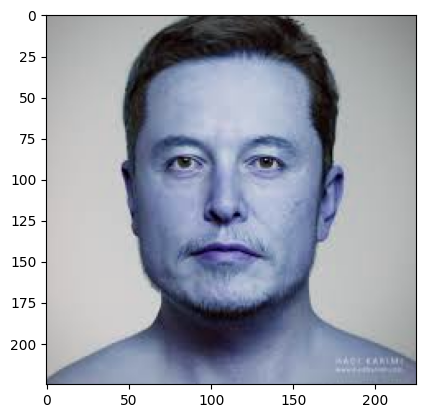

In [5]:
plt.imshow(img)

In [6]:
#to change into a gray image

In [7]:
gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(225, 225)

In [8]:
gray

array([[156, 157, 157, ..., 133, 132, 134],
       [156, 157, 157, ..., 133, 133, 134],
       [157, 157, 158, ..., 134, 134, 134],
       ...,
       [110, 111, 113, ..., 129, 127, 129],
       [ 96, 106, 118, ..., 128, 125, 129],
       [112, 113, 115, ..., 133, 133, 129]], dtype=uint8)

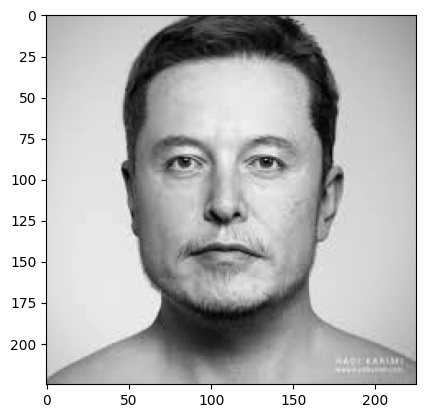

In [9]:
plt.imshow(gray, cmap='gray')

In [10]:
#detect the face and eyes

In [11]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[ 41,  34, 141, 141]], dtype=int32)

In [12]:
(x,y,w,h) = faces[0]
x,y,w,h

(41, 34, 141, 141)

In [13]:
#crop/draw rectangle around the face using opencv

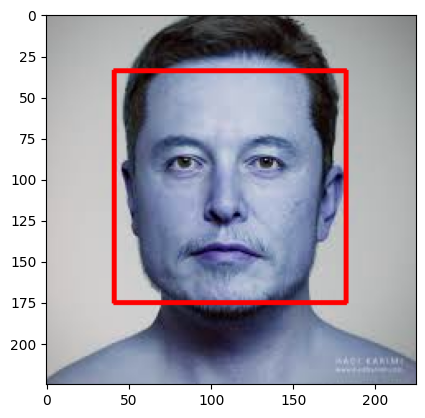

In [14]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

In [15]:
#detect the eyes

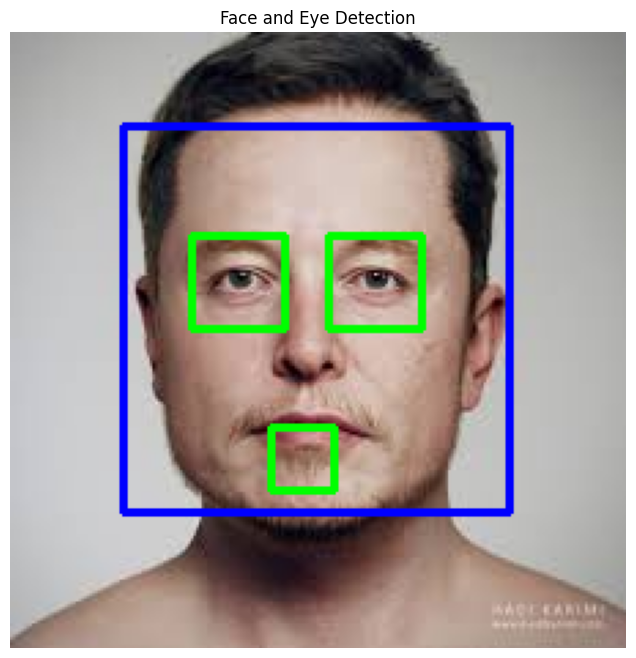

In [16]:
# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5,
    minSize=(30, 30)
)

# Make a copy so we don't draw on the original
face_img = img.copy()

for (x, y, w, h) in faces:
    # Draw blue rectangle around the face
    cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    
    # Extract the face region (ROI) in grayscale for eye detection
    roi_gray = gray[y:y + h, x:x + w]
    roi_color = face_img[y:y + h, x:x + w]   # same region but in color (for drawing)
    
    # Detect eyes inside this face
    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.05,     # smaller steps → better chance to find both eyes
        minNeighbors=3,
        minSize=(20, 20)
    )
    
    # Draw green rectangle around each detected eye
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

# ────────────────────────────────────────────────
# Show the result using matplotlib
# ────────────────────────────────────────────────

plt.figure(figsize=(10, 8))           # adjust size as you like
plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))   # convert BGR → RGB for correct colors
plt.title("Face and Eye Detection")
plt.axis('off')
plt.show()

# Optional: close OpenCV windows if you used them before
cv2.destroyAllWindows()

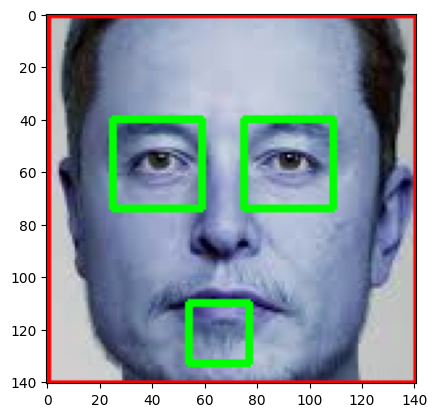

In [17]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [18]:
#crop the face region from all the images when the two eyes are detcted clealy

In [19]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >=2:
            return roi_color

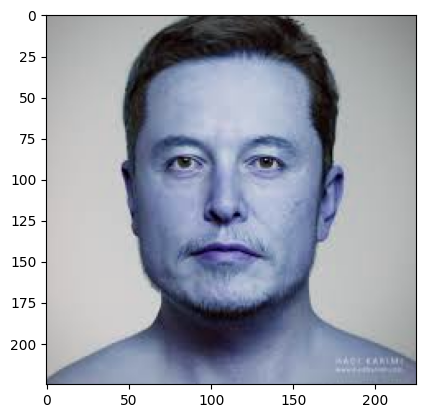

In [21]:
original_image = cv2.imread('./test_images/elon_musk35.jpg')
plt.imshow(original_image)

In [22]:
#crop the face out of the image

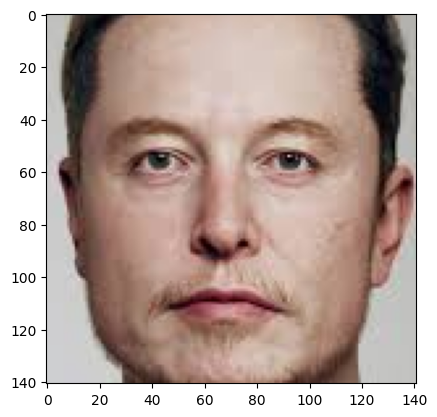

In [23]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/elon_musk35.jpg')

if cropped_image is not None:
    import cv2
    plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
    plt.axis("on")
else:
    print("Face with 2 eyes not detected")

In [24]:
path_to_data = './dataset/'
path_to_cr_data = './dataset/cropped'

In [25]:
import os

img_dirs = []

for entry in os.scandir(path_to_data):
    if entry.is_dir() and not entry.name.startswith("."):
        img_dirs.append(entry.path)

print(img_dirs)

['./dataset/lionel_messi', './dataset/Sam_Altman', './dataset/mark_zuckerberg', './dataset/cropped', './dataset/serena_williams', './dataset/elon_musk']


In [26]:
#if crop folder dosent exist, create it

In [27]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [28]:
#iterate through each of the image directory

In [29]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)

    celebrity_file_names_dict[celebrity_name] = []

    for entry in os.scandir(img_dir):

        # Skip non-files
        if not entry.is_file():
            continue

        # Read image safely
        img = cv2.imread(entry.path)
        if img is None:
            print("Skipped invalid image:", entry.path)
            continue

        roi_color = get_cropped_image_if_2_eyes(entry.path)

        if roi_color is not None:
            cropped_folder = path_to_cr_data + "/" + celebrity_name

            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                print("Generating cropped images in folder:", cropped_folder)
                cropped_image_dirs.append(cropped_folder)

            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name

            cv2.imwrite(cropped_file_path, roi_color)

            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

lionel_messi
Generating cropped images in folder: ./dataset/cropped/lionel_messi
Sam_Altman
Generating cropped images in folder: ./dataset/cropped/Sam_Altman
mark_zuckerberg
Generating cropped images in folder: ./dataset/cropped/mark_zuckerberg
Skipped invalid image: ./dataset/mark_zuckerberg/mark_zuckerberg232.html
Skipped invalid image: ./dataset/mark_zuckerberg/mark_zuckerberg231.html
cropped
serena_williams
Generating cropped images in folder: ./dataset/cropped/serena_williams
elon_musk
Generating cropped images in folder: ./dataset/cropped/elon_musk


In [30]:
#feature egineering

In [31]:
#using wavelet transform to extract features such as eyes, nose mouth etc

In [32]:
import numpy as np
import pywt
import cv2


def w2d(img, mode='haar', level=1):
    imArray = img

    # datatype conversions
    # convert to grayscale
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)

    # convert to float
    imArray = np.float32(imArray)
    imArray /= 255

    # compute coefficients
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    # process coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    # reconstruction
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

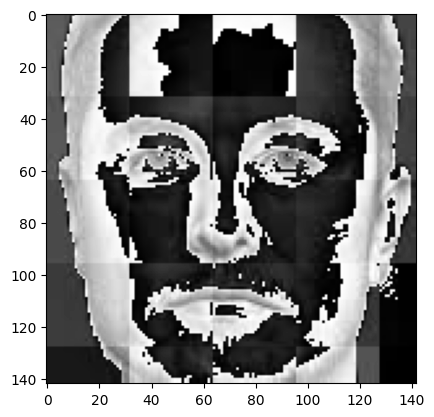

In [33]:
im_har = w2d(cropped_image, 'db1', 5)
plt.imshow(im_har, cmap='gray')

In [34]:
#create wavelet transform image for all our image folder and vertically stack them

In [35]:
celebrity_file_names_dict

{'lionel_messi': ['./dataset/cropped/lionel_messi/lionel_messi1.png',
  './dataset/cropped/lionel_messi/lionel_messi2.png',
  './dataset/cropped/lionel_messi/lionel_messi3.png',
  './dataset/cropped/lionel_messi/lionel_messi4.png',
  './dataset/cropped/lionel_messi/lionel_messi5.png',
  './dataset/cropped/lionel_messi/lionel_messi6.png',
  './dataset/cropped/lionel_messi/lionel_messi7.png',
  './dataset/cropped/lionel_messi/lionel_messi8.png',
  './dataset/cropped/lionel_messi/lionel_messi9.png',
  './dataset/cropped/lionel_messi/lionel_messi10.png',
  './dataset/cropped/lionel_messi/lionel_messi11.png',
  './dataset/cropped/lionel_messi/lionel_messi12.png',
  './dataset/cropped/lionel_messi/lionel_messi13.png',
  './dataset/cropped/lionel_messi/lionel_messi14.png',
  './dataset/cropped/lionel_messi/lionel_messi15.png',
  './dataset/cropped/lionel_messi/lionel_messi16.png',
  './dataset/cropped/lionel_messi/lionel_messi17.png',
  './dataset/cropped/lionel_messi/lionel_messi18.png',
  '

In [36]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'lionel_messi': 0,
 'Sam_Altman': 1,
 'mark_zuckerberg': 2,
 'cropped': 3,
 'serena_williams': 4,
 'elon_musk': 5}

In [37]:
x, y = [], []

for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)

        if img is None:
            continue

        scaled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img, 'db1', 5)
        scaled_img_har = cv2.resize(img_har, (32, 32))

        combined_img = np.vstack((
            scaled_raw_img.reshape(32*32*3, 1),
            scaled_img_har.reshape(32*32, 1)
        ))

        x.append(combined_img)
        y.append(class_dict[celebrity_name])

In [38]:
len(x)

455

In [39]:
x = np.array(x).reshape(len(x),4096).astype(float)
x.shape

(455, 4096)

In [40]:
x[0]

array([60., 48., 44., ...,  1.,  0.,  0.])

In [41]:
#using support vector machine to train the model

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

pipe = Pipeline([
    ('scalar', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10))
])

pipe.fit(x_train, y_train)
pipe.score(x_test, y_test)

0.9298245614035088

In [43]:
len(x_test)

114

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pipe.predict(x_test)))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        25
           1       0.67      0.67      0.67         3
           2       0.91      1.00      0.95        67
           4       1.00      1.00      1.00        15
           5       1.00      0.50      0.67         4

    accuracy                           0.93       114
   macro avg       0.91      0.79      0.83       114
weighted avg       0.94      0.93      0.93       114



In [45]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [46]:
model_params = {
    'svm': {
        'model': SVC(gamma='auto', probability=True),
        'params': {
            'svc__C': [1, 10, 100, 1000],
            'svc__kernel': ['rbf', 'linear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'randomforestclassifier__n_estimators': [5, 10, 50, 100]
        }
    },
    'logistic_regression': {
        'model': LogisticRegression(solver='liblinear', multi_class='auto'),
        'params': {
            'logisticregression__C': [0.1, 1, 5, 10]
        }
    }
}

In [50]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(),mp['model'])
    clf = GridSearchCV(pipe,mp['params'], cv=5, return_train_score=False)
    clf.fit(x_train, y_train)
    
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    
    best_estimators[algo] = clf.best_estimator_

# Create summary DataFrame
df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
df

,model,best_score,best_params
0,svm,0.909207,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.815303,{'randomforestclassifier__n_estimators': 100}
2,logistic_regression,0.923700,{'logisticregression__C': 0.1}


In [51]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier', RandomForestClassifier())]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=0.1, solver='liblinear'))])}

In [52]:
best_estimators['random_forest'].score(x_test, y_test)

0.8596491228070176

In [53]:
best_estimators['svm'].score(x_test, y_test)

0.9298245614035088

In [54]:
best_estimators['logistic_regression'].score(x_test, y_test)

0.9298245614035088

In [55]:
#store svm into my best classifier because for model training

In [56]:
best_clf = best_estimators['svm']

In [57]:
#using confussion metrix,

In [58]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(x_test))
cm

array([[21,  2,  1,  1,  0],
       [ 0,  2,  1,  0,  0],
       [ 2,  0, 65,  0,  0],
       [ 0,  1,  0, 14,  0],
       [ 0,  0,  0,  0,  4]])

Text(95.72222222222221, 0.5, 'Truth')

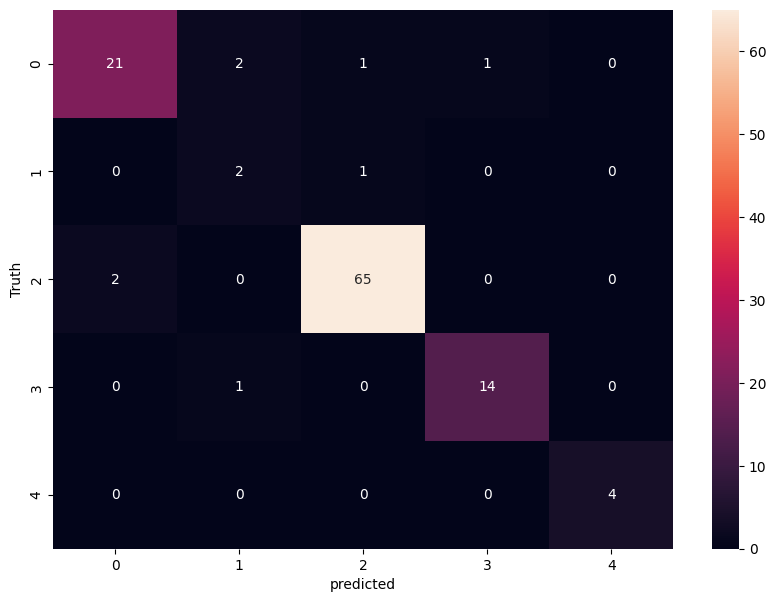

In [59]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot = True)
plt.xlabel('predicted')
plt.ylabel('Truth')

In [60]:
class_dict

{'lionel_messi': 0,
 'Sam_Altman': 1,
 'mark_zuckerberg': 2,
 'cropped': 3,
 'serena_williams': 4,
 'elon_musk': 5}

In [61]:
#now save our model to a file

In [62]:
import joblib
joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']

In [64]:
import json
with open('class_dictionary.json', 'w')as f:
    f.write(json.dumps(class_dict))